In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import psi_params, ellipse_aspect_ratio, unit_det

import re
def extract_number(s):
    match = re.search(r'\d+', s)
    return int(match.group()) if match else None


In [2]:
def solo(l, VT, VN, core_thresh=30_000, plot=False, ax=None):
    from scipy.optimize import curve_fit

    l, VT, VN = map(np.asarray, (l, VT, VN))
    m = np.isfinite(l) & np.isfinite(VT) & np.isfinite(VN)
    l, VT, VN = l[m], VT[m], VN[m]

    if l.size < 4:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    def vn_model(l, x0, C, D):
        dl = l - x0
        return C * dl + D * dl**3

    def vt_model(l, x0, A, B):
        dl = l - x0
        return A + B * dl**2

    def fit_x0_from_vn(l, VN):
        x0_guess = l[np.argmin(np.abs(VN))]
        C_guess = 0.0
        D_guess = 0.0

        try:
            popt, _ = curve_fit(
                vn_model, l, VN,
                p0=[x0_guess, C_guess, D_guess],
                maxfev=10000
            )
            return popt
        except Exception:
            return np.array([np.nan, np.nan, np.nan])

    x0, C, D = fit_x0_from_vn(l, VN)
    if not np.isfinite(x0):
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # focus on core
    mask = np.abs(l - x0) <= core_thresh
    l, VT, VN = l[mask], VT[mask], VN[mask]

    # refit
    x0, C, D = fit_x0_from_vn(l, VN)
    if not np.isfinite(x0):
        return np.nan, np.nan, np.nan, np.nan, np.nan

    dl = l - x0

    Xu = np.vstack([np.ones_like(dl), dl**2]).T
    A, B = np.linalg.lstsq(Xu, VT, rcond=None)[0]

    l0 = x0
    r0 = A / C
    Q = np.array([[1., 0.], [0., 1.]])
    Omega =  C # -C
    w = 2 * Omega

    if plot:
        lfit = np.linspace(l.min(), l.max(), 500)

        if ax is None:
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        else:
            axs = ax

        axs = np.asarray(axs).ravel()

        axs[0].scatter(l, VN)
        axs[0].plot(lfit, vn_model(lfit, x0, C, D))
        axs[0].axvline(x0, linestyle='--')
        axs[0].axhline(0, linewidth=0.8)
        axs[0].set_xlabel('l')
        axs[0].set_ylabel('VN')
        axs[0].set_title('VN fit')

        axs[1].scatter(l, VT)
        axs[1].plot(lfit, vt_model(lfit, x0, A, B))
        axs[1].axvline(x0, linestyle='--')
        axs[1].set_xlabel('l')
        axs[1].set_ylabel('VT')
        axs[1].set_title('VT fit')

        if ax is None:
            plt.tight_layout()
            plt.show()

    U = A*np.ones(len(dl))
    V = C*dl

    return l0, r0, w, Q, Omega, U, V
    
    

In [3]:
def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    ci_flag=False,
    pred_flag=False,
    clr='b'
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]
    
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        # r_grid = np.linspace(0, rho_plot_max, n_curve)
        r_grid = np.linspace(0.0, 110, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=40, marker='x', zorder=2, color=clr)

        mask = r_grid<=rho_plot_max
        ax.plot(r_grid[mask], np.abs(vt_grid[mask]), lw=2, color='c', zorder=1)
        ax.plot(r_grid[~mask], np.abs(vt_grid[~mask]), lw=2, color='c', zorder=1, alpha=.3)
        # ax.plot(r_grid, np.abs(vt_grid), lw=2, color=clr, label='')
        
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color=clr, label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        # ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [4]:
width=500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1., 0., 1.
psi0 = 250.
Rc = 85.0
A = - psi0 / Rc**2 


# rescale Q to have unit determinant
Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

w = 2*A*(q11+q22)*1e-3
Omega = 2*A

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
psi = psi0 * np.exp( - rho2 / Rc**2 )
u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2


Axes(0.125,0.53;0.227941x0.35)
Axes(0.398529,0.53;0.227941x0.35)
Axes(0.672059,0.53;0.227941x0.35)
Axes(0.125,0.11;0.227941x0.35)
Axes(0.398529,0.11;0.227941x0.35)
Axes(0.672059,0.11;0.227941x0.35)


,xc,yc,w,q11,q12,q22,Rc,psi0,A,Omega
Control,0.000000e+00,0.000000,-0.000138,1.0,0.0,1.0,85.000000,250.000000,-0.000035,-0.000069
P1,0.000000e+00,-0.643841,-0.000136,1.0,0.0,1.0,86.113585,252.937780,NaN,-0.000068
P2,7.179040e-10,-1.609602,-0.000136,1.0,0.0,1.0,86.324602,253.408999,NaN,-0.000068
P3,3.002654e-09,-2.575363,-0.000139,1.0,0.0,1.0,85.883518,257.198220,NaN,-0.000070
L1,6.929213e-11,-0.084143,-0.000138,1.0,0.0,1.0,85.486119,252.036601,NaN,-0.000069
L2,0.000000e+00,-0.643841,-0.000136,1.0,0.0,1.0,86.113585,252.937780,NaN,-0.000068
L3,0.000000e+00,-2.113639,-0.000134,1.0,0.0,1.0,86.755294,251.962366,NaN,-0.000067


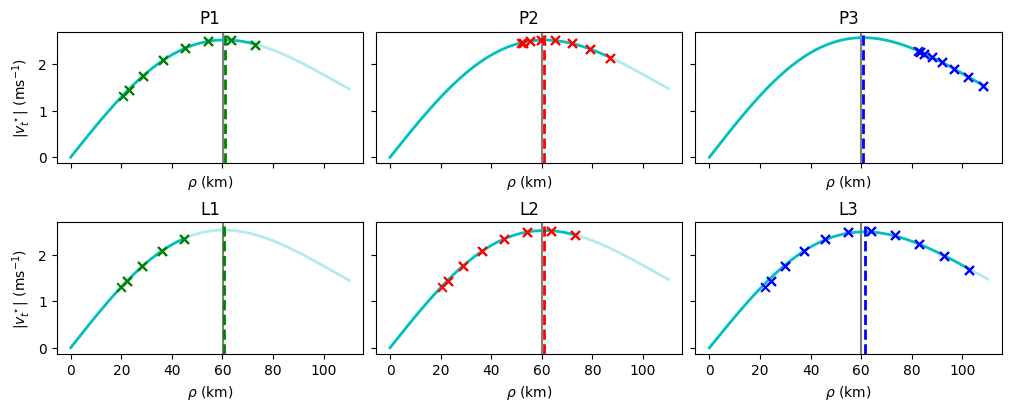

In [5]:
df_res = pd.DataFrame({'xc': [xc], 'yc': [yc], 'w': [w], 'q11': [q11], 'q12': [q12], 'q22': [q22],
                        'Rc': [Rc], 'psi0': [psi0], 'A': [A*1e-3], 'Omega': Omega*1e-3})

nic, njc = 50, 60
r = 14

df_tests = pd.DataFrame({
    'nic': [nic, nic, nic, nic, nic, nic],
    'njc': [54, njc, 66, 54, 54, 54],
    'r': [r, r, r, 8, r, 20]
}, index=['P1', 'P2', 'P3', 'L1', 'L2', 'L3'])

df_tests = df_tests*5

dic_tests = {}

fig, axs = plt.subplots(2, 3, constrained_layout=True, figsize=(10, 4), sharey=True, sharex=True)
axs = axs.flatten()

skip = 10
clrs = ['g', 'r', 'b']*2
for t, test in enumerate(df_tests.index):
    data = df_tests.loc[test]

    x1 = x[data.nic-data.r:data.nic+data.r+1:skip]
    y1 = np.array([y[data.njc]] * len(x1))
    l = x1 - x1[0]
    
    u1 = u[data.nic-data.r:data.nic+data.r+1:skip, data.njc]
    v1 = v[data.nic-data.r:data.nic+data.r+1:skip, data.njc]

    l0, r0, w_moc, Q_moc, Omega_moc, UU, VV = solo(l, u1, v1, plot=False)
    xc_moc, yc_moc = l0 + x1[0], r0 + y1[0]
    w_moc *= 1e-3

    df = psi_params(xc_moc, yc_moc, Q_moc, x1, y1, u1, v1)
    Rc_moc, psi0_moc, Omega_moc = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega_moc, r2_flag=False, 
                                     plot=True, Rc_max=1e6, clr=clrs[t], ax=axs[t])
    print(axs[t])

    # using updated A
    Omega_moc *= 1e-3
    w_moc = Omega_moc*(Q_moc[0,0] + Q_moc[1,1])
                      
    dic_tests[test] = {'x1': x1, 'y1': y1, 'l': l, 'u1': u1, 'v1': v1, 'name': test, 'UU': UU, 'VV': VV}
    df_res.loc[len(df_res)] = {'xc': xc_moc, 'yc': yc_moc, 'w': w_moc,
                               'q11': Q_moc[0,0], 'q12': Q_moc[0,1], 'q22': Q_moc[1,1],
                               'Rc': Rc_moc, 'psi0': psi0_moc, 'Omega': Omega_moc}

for a, ax in enumerate(axs):
    # if a%2==0:
    ax.set_title(df_tests.index[a])
    ax.set_xlabel(r'$\rho$ (km)')
    ax.axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)
    if a in [0, 3]:
        ax.set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)')
    else:
        ax.set_ylabel('')
    
df_res.index = ['Control'] +  list(df_tests.index)
df_res


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


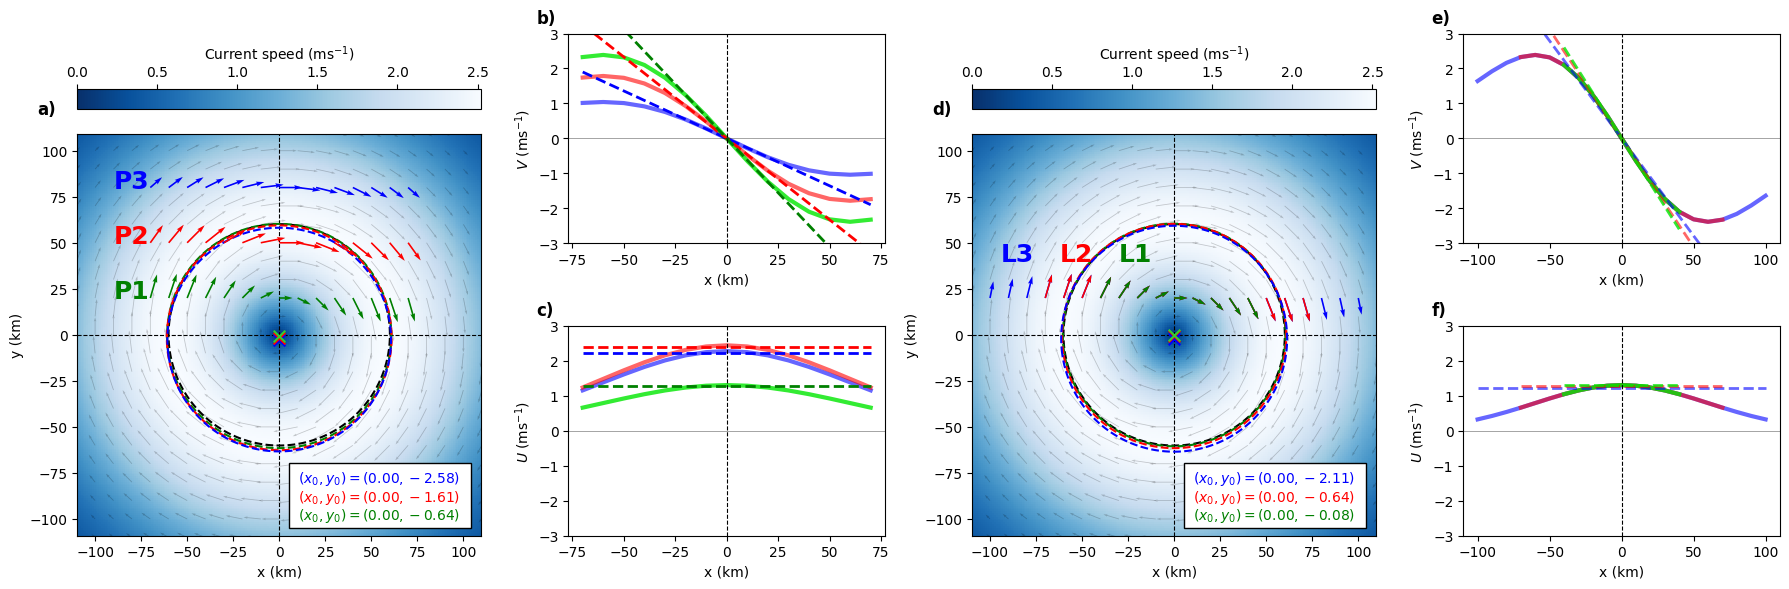

In [6]:
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[1, 1, 2, 1, 1, 2])  # Adjust width ratios

# LEFT PLOT (PLOT A)
ax_main_left = fig.add_subplot(gs[:, :2])
pc = ax_main_left.pcolor(x, y, np.hypot(u, v), cmap='Blues_r', zorder=0)
plt.colorbar(pc, ax=ax_main_left, orientation='horizontal', location='top', label=r'Current speed (ms$^{-1}$)')
ax_main_left.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=0)
ax_main_left.axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=0)

spacing = 2*5
scale = 40
width = 0.002
alpha = 1
quiv = ax_main_left.quiver(x[::spacing], y[::spacing], u[::spacing, ::spacing].T, v[::spacing, ::spacing].T,
                           alpha=.2, scale=scale, width=width, zorder=1)

ax_main_left.contour(X, Y, rho2, levels=[Rc**2/2],
                     colors='k', linestyles='--')

colors = ['limegreen', 'r', 'b']
color = ['g', 'r', 'b']
color_fits = [(0, .9, 0, 0.8), (1, 0, 0, 0.6), (0, 0, 1, 0.6)]
i = 0
for dic in dic_tests.values():
    if 'P' in dic['name']:
        x1, y1, l, u1, v1 = dic['x1'], dic['y1'], dic['l'], dic['u1'], dic['v1']
        data = df_res.loc[dic['name']]
        
        ax_main_left.text(x1[0]-20, y1[0], dic['name'], color=color[i],
                          zorder=3, fontsize=18, fontweight='bold')
        ax_main_left.quiver(x1, y1, u1, v1,
                            scale=scale, width=width*2, color=color[i], zorder=3)
        ax_main_left.scatter(data.xc, data.yc, color=colors[i], marker='x', s=70, zorder=10-extract_number(dic['name']))

        dx_ell, dy_ell = X - data.xc, Y - data.yc
        rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
        ax_main_left.contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=color[i], linestyles='--')
        
        ax_main_left.text(10, (-100 + 10*i), fr'$(x_0,y_0)=({np.abs(data.xc):.2f},{data.yc:.2f})$',
                          color=color[i], zorder=10)

        i += 1
        
x_pos, y_pos = 0.75, 0.1
box_width = 0.45  # Adjust width as needed
box_height = 0.16 #0.07  # Adjust height as needed
rect = Rectangle((x_pos - box_width / 2, y_pos - box_height / 2), 
                       box_width, box_height, transform=ax_main_left.transAxes,
                       facecolor='white', edgecolor='black', zorder=9)
ax_main_left.add_patch(rect)
ax_main_left.axis('equal')
ax_main_left.set_xlim(-100, 100)
ax_main_left.set_ylim(-100, 100)
ax_main_left.set_xlabel('x (km)')
ax_main_left.set_ylabel('y (km)')
ax_main_left.text(-0.1, 1.05, 'a)', transform=ax_main_left.transAxes, fontsize=12, fontweight='bold')

# Subplot columns (2x1 on the right)
ax2_left = fig.add_subplot(gs[0, 2])
ax3_left = fig.add_subplot(gs[1, 2])

j = 0
for dic in dic_tests.values():
    if 'P' in dic['name']:

        x1, y1, l, u1, v1, UU, VV = dic['x1'], dic['y1'], dic['l'], dic['u1'], dic['v1'], dic['UU'], dic['VV']
        data = df_res.loc[dic['name']]
        
        ax2_left.plot(x1, v1, color=color_fits[j], linewidth=3, zorder=-extract_number(dic['name'])-3)
        ax2_left.plot(x1, VV, color=color[j], linestyle='--', linewidth=2, zorder=-extract_number(dic['name']))

        ax3_left.plot(x1, u1, color=color_fits[j], linewidth=3, zorder=-extract_number(dic['name'])-3)
        ax3_left.plot(x1, UU, color=color[j], linestyle='--', linewidth=2, zorder=-extract_number(dic['name']))
        
        j += 1

# ax2_left.text(3, .13, r'$x_0$')
# ax3_left.text(3, .13, r'$x_0$')
        
ax2_left.axvline(x1[len(x1) // 2], color='black', linewidth=0.8, linestyle='--', zorder=2)
ax2_left.axhline(y=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
ax2_left.set_ylabel(r'$V$ (ms$^{-1}$)')
ax2_left.set_xlabel('x (km)')
ax2_left.text(-0.1, 1.05, 'b)', transform=ax2_left.transAxes, fontsize=12, fontweight='bold')
ax3_left.axvline(x1[len(x1) // 2], color='black', linewidth=0.8, linestyle='--', zorder=2)
ax3_left.axhline(y=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
ax3_left.set_ylabel(r'$U$ (ms$^{-1}$)')
ax3_left.set_xlabel('x (km)')
ax3_left.text(-0.1, 1.05, 'c)', transform=ax3_left.transAxes, fontsize=12, fontweight='bold')

# Right PLOT (PLOT B)
ax_main_right = fig.add_subplot(gs[:, 3:5])
pc = ax_main_right.pcolor(x, y, np.hypot(u, v), cmap='Blues_r')
plt.colorbar(pc, ax=ax_main_right, orientation='horizontal', location='top', label=r'Current speed (ms$^{-1}$)')
ax_main_right.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=2)
ax_main_right.axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=2)
quiv = ax_main_right.quiver(x[::spacing], y[::spacing],
                            u[::spacing, ::spacing].T, v[::spacing, ::spacing].T,
                            alpha=.2, scale=scale, width=width)

ax_main_right.contour(X, Y, rho2, levels=[Rc**2/2],
                     colors='k', linestyles='--')

i = 0
for dic in dic_tests.values():
    if 'L' in dic['name']:
        x1, y1, l, u1, v1 = dic['x1'], dic['y1'], dic['l'], dic['u1'], dic['v1']
        data = df_res.loc[dic['name']]
        
        ax_main_right.quiver(x1, y1, u1, v1,
                             scale=scale, width=width*2, color=color[i], zorder=5-i)
        ax_main_right.scatter(data.xc, data.yc, color=colors[i], marker='x', s=70, zorder=10-extract_number(dic['name']))
        ax_main_right.text(10, (-100 + 10*i), fr'$(x_0,y_0)=({np.abs(data.xc):.2f},{data.yc:.2f})$',
                           color=color[i], zorder=10)

        dx_ell, dy_ell = X - data.xc, Y - data.yc
        rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
        ax_main_right.contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=color[i], linestyles='--')

        ax_main_right.text(x1[0]+(-i*2 +10), y1[0]+20, dic['name'],
                           color=color[i], zorder=3, fontsize=18, fontweight='bold')
 
        i += 1
x_pos, y_pos = 0.75, 0.1
box_width = 0.45  # Adjust width as needed
box_height = 0.16 #0.07  # Adjust height as needed
rect = Rectangle((x_pos - box_width / 2, y_pos - box_height / 2), 
                       box_width, box_height, transform=ax_main_right.transAxes,
                       facecolor='white', edgecolor='black', zorder=9)
ax_main_right.add_patch(rect)
ax_main_right.axis('equal')
ax_main_right.set_xlim(-100, 100)
ax_main_right.set_ylim(-100, 100)
ax_main_right.set_xlabel('x (km)')
ax_main_right.set_ylabel('y (km)')
ax_main_right.text(-0.1, 1.05, 'd)', transform=ax_main_right.transAxes, fontsize=12, fontweight='bold')

# Subplot columns (2x1 on the right)
ax2_right = fig.add_subplot(gs[0, 5])
ax3_right = fig.add_subplot(gs[1, 5])

j = 0
for dic in dic_tests.values():
    if 'L' in dic['name']:
        x1, y1, l, u1, v1, UU, VV = dic['x1'], dic['y1'], dic['l'], dic['u1'], dic['v1'], dic['UU'], dic['VV']
        data = df_res.loc[dic['name']]

        ax2_right.plot(x1, v1, color=color_fits[j], linewidth=3, zorder=-extract_number(dic['name']))
        ax2_right.plot(x1, VV, color=color_fits[j], linestyle='--', linewidth=2, zorder=3-extract_number(dic['name']))

        ax3_right.plot(x1, u1, color=color_fits[j], linewidth=3, zorder=-extract_number(dic['name']))
        ax3_right.plot(x1, UU, color=color_fits[j], linestyle='--', linewidth=2, zorder=3-extract_number(dic['name']))

        j += 1

# ax2_right.text(3, .13, r'$x_0$')
# ax3_right.text(3, .13, r'$x_0$')

ax2_right.axvline(x1[len(x1) // 2], color='black', linewidth=0.8, linestyle='--', zorder=2)
ax2_right.axhline(y=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
ax2_right.set_ylabel(r'$V$ (ms$^{-1}$)')
ax2_right.text(-0.1, 1.05, 'e)', transform=ax2_right.transAxes, fontsize=12, fontweight='bold')
ax2_right.set_xlabel('x (km)')

ax3_right.axvline(x1[len(x1) // 2], color='black', linewidth=0.8, linestyle='--', zorder=2)
ax3_right.axhline(y=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
ax3_right.set_ylabel(r'$U$ (ms$^{-1}$)')
ax3_right.set_xlabel('x (km)')
ax3_right.text(-0.1, 1.05, 'f)', transform=ax3_right.transAxes, fontsize=12, fontweight='bold')
ax3_right.set_xlabel('x (km)')


axs = [ax2_left, ax3_left, ax2_right, ax3_right]
ymin, ymax = np.inf, -np.inf
for ax in axs:
    ymin = min(ymin, ax.get_ylim()[0])
    ymax = max(ymax, ax.get_ylim()[1])

ymin, ymax = -3, 3
for ax in axs:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()


In [7]:
df_res


,xc,yc,w,q11,q12,q22,Rc,psi0,A,Omega
Control,0.000000e+00,0.000000,-0.000138,1.0,0.0,1.0,85.000000,250.000000,-0.000035,-0.000069
P1,0.000000e+00,-0.643841,-0.000136,1.0,0.0,1.0,86.113585,252.937780,NaN,-0.000068
P2,7.179040e-10,-1.609602,-0.000136,1.0,0.0,1.0,86.324602,253.408999,NaN,-0.000068
P3,3.002654e-09,-2.575363,-0.000139,1.0,0.0,1.0,85.883518,257.198220,NaN,-0.000070
L1,6.929213e-11,-0.084143,-0.000138,1.0,0.0,1.0,85.486119,252.036601,NaN,-0.000069
L2,0.000000e+00,-0.643841,-0.000136,1.0,0.0,1.0,86.113585,252.937780,NaN,-0.000068
L3,0.000000e+00,-2.113639,-0.000134,1.0,0.0,1.0,86.755294,251.962366,NaN,-0.000067


In [8]:
df_paper = df_res.copy()
df_paper = df_paper.drop(columns=['q11', 'q12', 'q22', 'A'])
df_paper


,xc,yc,w,Rc,psi0,Omega
Control,0.000000e+00,0.000000,-0.000138,85.000000,250.000000,-0.000069
P1,0.000000e+00,-0.643841,-0.000136,86.113585,252.937780,-0.000068
P2,7.179040e-10,-1.609602,-0.000136,86.324602,253.408999,-0.000068
P3,3.002654e-09,-2.575363,-0.000139,85.883518,257.198220,-0.000070
L1,6.929213e-11,-0.084143,-0.000138,85.486119,252.036601,-0.000069
L2,0.000000e+00,-0.643841,-0.000136,86.113585,252.937780,-0.000068
L3,0.000000e+00,-2.113639,-0.000134,86.755294,251.962366,-0.000067


In [9]:
df_err = (df_paper - df_paper.iloc[0]).abs().iloc[1:]
df_err.index = ['P1 Err', 'P2 Err', 'P3 Err',
                'L1 Err', 'L2 Err', 'L3 Err']
df_err


,xc,yc,w,Rc,psi0,Omega
P1 Err,0.000000e+00,0.643841,1.971872e-06,1.113585,2.937780,9.859358e-07
P2 Err,7.179040e-10,1.609602,2.385146e-06,1.324602,3.408999,1.192573e-06
P3 Err,3.002654e-09,2.575363,1.070527e-06,0.883518,7.198220,5.352636e-07
L1 Err,6.929213e-11,0.084143,4.549045e-07,0.486119,2.036601,2.274523e-07
L2 Err,0.000000e+00,0.643841,1.971872e-06,1.113585,2.937780,9.859358e-07
L3 Err,0.000000e+00,2.113639,4.501177e-06,1.755294,1.962366,2.250588e-06


#### Simpler display of MOCA improvements

/scratch/pbs.7564910.kman.restech.unsw.edu.au/ipykernel_1741743/2532622074.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Actual vorticity -6.920415224913495e-05
SOLO Omega: -6.920415224913498e-05
2.842170943040401e-14
MOCA Omega: -2.124768947622342e-05
-25.799745794902734


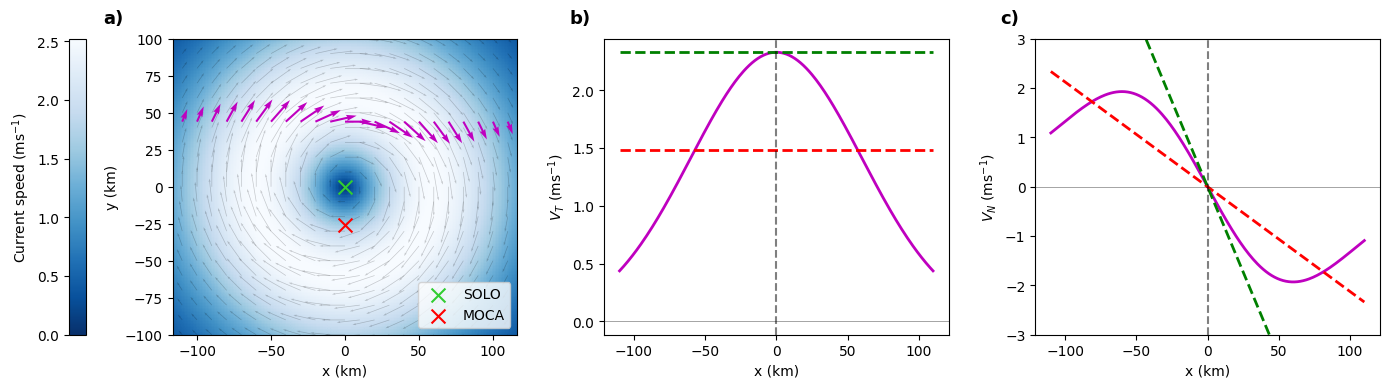

In [10]:
from matplotlib.gridspec import GridSpec

i1, i2 = 140, 360
j = 294

scale = 30
width = 0.002

x1 = x[i1:i2+1]
y1 = [y[j]] * len(x1)

u1 = u[i1:i2+1, j]
v1 = v[i1:i2+1, j]

VT = -2*A*(q22*(y[j]-yc)+q12*(x1-xc))
VN =  2*A*(q11*(x1-xc)+q12*(y[j]-yc))

spac = 2*5

fig = plt.figure(figsize=(14,4))

# 4 columns: [COLORBAR | AX0 | AX1 | AX2]
gs = GridSpec(1, 4, width_ratios=[0.05, 1, 1, 1], figure=fig)

cax = fig.add_subplot(gs[0, 0])
axs = [fig.add_subplot(gs[0, i]) for i in range(1, 4)]  # axs[0], axs[1], axs[2]

im = axs[0].pcolor(X, Y, np.hypot(u, v), cmap='Blues_r')
fig.colorbar(im, cax=cax, location='left', label=r'Current speed (ms$^{-1}$)')


axs[0].quiver(X[::spac,::spac], Y[::spac,::spac], u[::spac,::spac], v[::spac,::spac],
             scale=scale, width=width, alpha=.2)
axs[0].quiver(x1[::spac], y1[::spac], u1[::spac], v1[::spac],
              color='m', scale=scale, width=width*3)

print(f'Actual vorticity {df_res.iloc[0].Omega}')

l0, r0, w_check, _, Omega_check, _, _ = solo(x1-x1[0], VT, VN)  # l0, r0, w, Q, Omega, U, V
x0 = x1[0] + l0
y0 = y1[0] + r0
print(f'SOLO Omega: {Omega_check*1e-3}')
print(y0)
axs[0].scatter(x0, y0, marker='x', color='limegreen', s=100, label='SOLO')#, $\omega={Omega}$')

pf_u = np.poly1d(np.polyfit(x1, u1, 0))
pf_v = np.poly1d(np.polyfit(x1, v1, 1))
Omega1 = pf_v[1]
print(f'MOCA Omega: {Omega1*1e-3}')

r01 = pf_u[0] / Omega1
l01 = -x1[0]
x01, y01 = x1[0] + l01, r01 + y1[0]
print(y01)
axs[0].scatter(x01, y01, marker='x', color='r', s=100, label='MOCA')#,\n $\omega={Omega1}$')

axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)')
axs[0].axis('equal'); axs[0].legend(loc='lower right')
axs[0].set_xlim(-100, 100)
axs[0].set_ylim(-100, 100)
axs[0].text(-.2, 1.1, 'a)', transform=axs[0].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

axs[1].plot(x1, u1, 'm', lw=2)
axs[1].plot(x1, pf_u(x1), ls='--', color='r', lw=2)
axs[1].plot(x1, [np.max(u1)] * len(x1), ls='--', color='g', lw=2)
axs[1].axvline(x=0, ls='--', color='k', alpha=.5)
axs[1].axhline(y=0, lw=.5, color='k', alpha=.5)
axs[1].set_xlabel('x (km)'); axs[1].set_ylabel(r'$V_T$ (ms$^{-1}$)')
axs[1].text(-.1, 1.1, 'b)', transform=axs[1].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

axs[2].plot(x1, v1, 'm', lw=2)
axs[2].plot(x1, pf_v(x1), ls='--', color='r', lw=2)
axs[2].plot(x1, Omega*x1, ls='--', color='g', lw=2)
axs[2].axvline(x=0, ls='--', color='k', alpha=.5)
axs[2].axhline(y=0, lw=.5, color='k', alpha=.5)
# axs[2].text(4,0.1, r'$x_0$')
axs[2].set_ylim(-3, 3)
axs[2].set_xlabel('x (km)'); axs[2].set_ylabel(r'$V_N$ (ms$^{-1}$)') 
axs[2].text(-.1, 1.1, 'c)', transform=axs[2].transAxes, fontsize=13, fontweight='bold', va='top', ha='left')

plt.tight_layout()


In [11]:
df_paper

,xc,yc,w,Rc,psi0,Omega
Control,0.000000e+00,0.000000,-0.000138,85.000000,250.000000,-0.000069
P1,0.000000e+00,-0.643841,-0.000136,86.113585,252.937780,-0.000068
P2,7.179040e-10,-1.609602,-0.000136,86.324602,253.408999,-0.000068
P3,3.002654e-09,-2.575363,-0.000139,85.883518,257.198220,-0.000070
L1,6.929213e-11,-0.084143,-0.000138,85.486119,252.036601,-0.000069
L2,0.000000e+00,-0.643841,-0.000136,86.113585,252.937780,-0.000068
L3,0.000000e+00,-2.113639,-0.000134,86.755294,251.962366,-0.000067


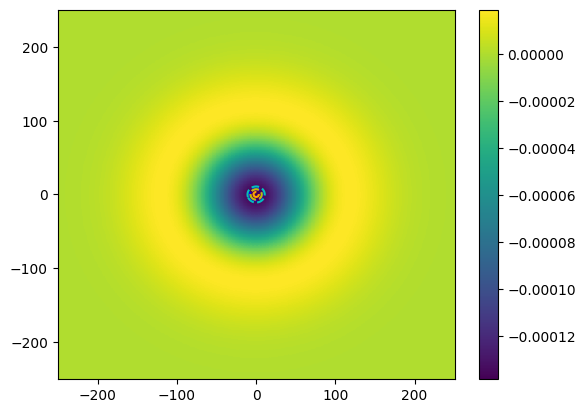

In [12]:
dx = (X[1,0] - X[0,0])*1e3
dy = (Y[0,1] - Y[0,0])*1e3

dv_dx = np.gradient(v, dx, axis=0)
du_dy = np.gradient(u, dy, axis=1)

zeta = dv_dx - du_dy
plt.pcolor(X, Y, zeta)
plt.colorbar()
clrs =['r', 'm', 'b', 'w', 'orange', 'y', 'c']
for i, clr in enumerate(clrs):
    plt.contour(X, Y, zeta, levels=[df_res.iloc[i].w], colors=clr) 
    

In [13]:
def deform_eddy(Q11=1., Q12=0., Q22=1.):
    width = 500
    x = np.linspace(-width//2, width//2, 501)
    y = np.linspace(-width//2, width//2, 501)
    X, Y = np.meshgrid(x, y, indexing='ij')

    xc, yc = 0.0, 0.0
    psi0 = 250.0
    Rc = 85.0
    A = -psi0 / Rc**2

    Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]], float))
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx, dy = X - xc, Y - yc
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    u =  psi0*np.exp(-rho2/Rc**2) * (2*q12*dx + 2*q22*dy) / Rc**2
    v = -psi0*np.exp(-rho2/Rc**2) * (2*q11*dx + 2*q12*dy) / Rc**2

    nic, njc, r = 250, 270, 70
    skip = 10
    x1 = x[nic-r:nic+r+1:skip]
    y1 = np.full_like(x1, y[njc])
    l  = x1 - x1[0]
    u1 = u[nic-r:nic+r+1:skip, njc]
    v1 = v[nic-r:nic+r+1:skip, njc]

    l0, r0, w_moc, Q_moc, Omega_moc, _, _ = solo(l, u1, v1)
    xc_moc, yc_moc = l0 + x1[0], r0 + y1[0]

    # true values
    w_true = 2 * A * (q11 + q22)
    Omega_true = A

    return {
        "xc": xc_moc, "yc": yc_moc, "w": w_moc,
        "q11": Q_moc[0,0], "q12": Q_moc[0,1], "q22": Q_moc[1,1],
        "Omega": Omega_moc,
        "xc_true": xc, "yc_true": yc, "w_true": w_true,
        "Q11_true": q11, "Q12_true": q12, "Q22_true": q22,
        "Rc_true": Rc, "psi0_true": psi0, "Omega_true": Omega_true
    }

rows = []
for q12_in in np.arange(0.0, 0.8 + 0.05, 0.05):
    rows.append(deform_eddy(Q12=q12_in))

df_deform_tests = pd.DataFrame(rows)
df_deform_tests


,xc,yc,w,q11,q12,q22,Omega,xc_true,yc_true,w_true,Q11_true,Q12_true,Q22_true,Rc_true,psi0_true,Omega_true
0,0.000000,-0.643841,-0.124462,1.0,0.0,1.0,-0.062231,0.0,0.0,-0.138408,1.000000,0.000000,1.000000,85.0,250.0,-0.034602
1,-0.965688,-0.564771,-0.124569,1.0,0.0,1.0,-0.062285,0.0,0.0,-0.138582,1.001252,0.050063,1.001252,85.0,250.0,-0.034602
2,-1.932762,-0.328663,-0.124896,1.0,0.0,1.0,-0.062448,0.0,0.0,-0.139106,1.005038,0.100504,1.005038,85.0,250.0,-0.034602
3,-2.902345,0.061095,-0.125457,1.0,0.0,1.0,-0.062728,0.0,0.0,-0.139992,1.011443,0.151717,1.011443,85.0,250.0,-0.034602
4,-3.875114,0.598602,-0.126274,1.0,0.0,1.0,-0.063137,0.0,0.0,-0.141262,1.020621,0.204124,1.020621,85.0,250.0,-0.034602
5,-4.851225,1.275284,-0.127380,1.0,0.0,1.0,-0.063690,0.0,0.0,-0.142947,1.032796,0.258199,1.032796,85.0,250.0,-0.034602
6,-5.830338,2.079929,-0.128812,1.0,0.0,1.0,-0.064406,0.0,0.0,-0.145091,1.048285,0.314485,1.048285,85.0,250.0,-0.034602
7,-6.811752,2.999040,-0.130618,1.0,0.0,1.0,-0.065309,0.0,0.0,-0.147754,1.067521,0.373632,1.067521,85.0,250.0,-0.034602
8,-7.794534,4.017442,-0.132857,1.0,0.0,1.0,-0.066428,0.0,0.0,-0.151016,1.091089,0.436436,1.091089,85.0,250.0,-0.034602
9,-8.777620,5.119011,-0.135600,1.0,0.0,1.0,-0.067800,0.0,0.0,-0.154988,1.119785,0.503903,1.119785,85.0,250.0,-0.034602


In [14]:
df_deform_tests['Err'] = np.hypot(df_deform_tests.xc, df_deform_tests.yc)
# Aspect Ratio
ARs = []
for k in range(len(df_deform_tests)):
    data = df_deform_tests.iloc[k]
    ARs.append(ellipse_aspect_ratio(data.Q11_true, data.Q12_true, data.Q22_true))
df_deform_tests['AR'] = ARs

df_deform_tests


,xc,yc,w,q11,q12,q22,Omega,xc_true,yc_true,w_true,Q11_true,Q12_true,Q22_true,Rc_true,psi0_true,Omega_true,Err,AR
0,0.000000,-0.643841,-0.124462,1.0,0.0,1.0,-0.062231,0.0,0.0,-0.138408,1.000000,0.000000,1.000000,85.0,250.0,-0.034602,0.643841,1.000000
1,-0.965688,-0.564771,-0.124569,1.0,0.0,1.0,-0.062285,0.0,0.0,-0.138582,1.001252,0.050063,1.001252,85.0,250.0,-0.034602,1.118713,1.051315
2,-1.932762,-0.328663,-0.124896,1.0,0.0,1.0,-0.062448,0.0,0.0,-0.139106,1.005038,0.100504,1.005038,85.0,250.0,-0.034602,1.960507,1.105542
3,-2.902345,0.061095,-0.125457,1.0,0.0,1.0,-0.062728,0.0,0.0,-0.139992,1.011443,0.151717,1.011443,85.0,250.0,-0.034602,2.902988,1.163160
4,-3.875114,0.598602,-0.126274,1.0,0.0,1.0,-0.063137,0.0,0.0,-0.141262,1.020621,0.204124,1.020621,85.0,250.0,-0.034602,3.921075,1.224745
5,-4.851225,1.275284,-0.127380,1.0,0.0,1.0,-0.063690,0.0,0.0,-0.142947,1.032796,0.258199,1.032796,85.0,250.0,-0.034602,5.016048,1.290994
6,-5.830338,2.079929,-0.128812,1.0,0.0,1.0,-0.064406,0.0,0.0,-0.145091,1.048285,0.314485,1.048285,85.0,250.0,-0.034602,6.190230,1.362770
7,-6.811752,2.999040,-0.130618,1.0,0.0,1.0,-0.065309,0.0,0.0,-0.147754,1.067521,0.373632,1.067521,85.0,250.0,-0.034602,7.442729,1.441153
8,-7.794534,4.017442,-0.132857,1.0,0.0,1.0,-0.066428,0.0,0.0,-0.151016,1.091089,0.436436,1.091089,85.0,250.0,-0.034602,8.768957,1.527525
9,-8.777620,5.119011,-0.135600,1.0,0.0,1.0,-0.067800,0.0,0.0,-0.154988,1.119785,0.503903,1.119785,85.0,250.0,-0.034602,10.161244,1.623688


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


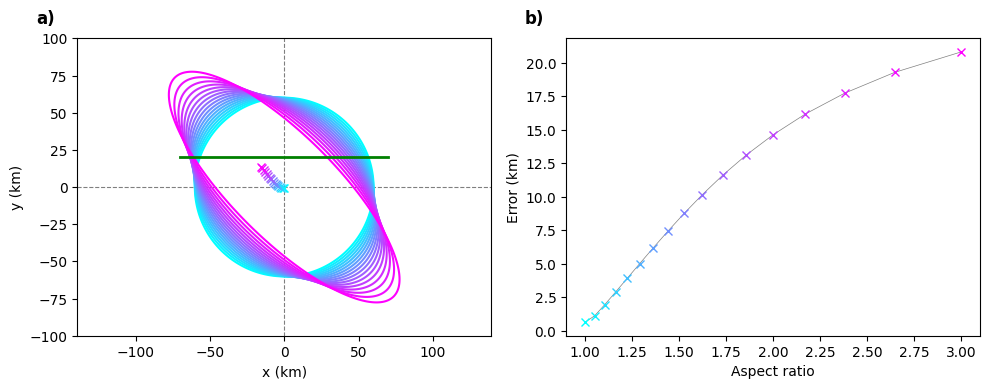

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))

N = len(df_deform_tests)
cmap = plt.cm.cool
cols = cmap(np.linspace(0, 1, N))

# ------------------ RIGHT panel (was left) ------------------
axs[1].plot(df_deform_tests.AR, df_deform_tests.Err, lw=.5, color='k', alpha=.5)
for i, (ar, err) in enumerate(zip(df_deform_tests.AR, df_deform_tests.Err)):
    axs[1].plot(ar, err, marker='x', color=cols[i])

axs[1].set_xlabel('Aspect ratio')
axs[1].set_ylabel('Error (km)')

# ------------------ Grid ------------------
width = 500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

# ------------------ LEFT panel (was right) ------------------
for i, (q11, q12, q22) in enumerate(zip(df_deform_tests.Q11_true,
                                      df_deform_tests.Q12_true,
                                      df_deform_tests.Q22_true)):
    rho2 = q11*X**2 + 2*q12*X*Y + q22*Y**2

    axs[0].contour(
        X, Y, rho2,
        levels=[Rc**2/2],
        colors=[cols[i]],
        linewidths=1.5
    )

for i, (xc_, yc_) in enumerate(zip(df_deform_tests.xc, df_deform_tests.yc)):
    axs[0].plot(xc_, yc_, marker='x', color=cols[i])

# reference transect
nic_, njc_, r_ = 250, 270, 70
x1 = x[nic_-r_:nic_+r_+1:skip]
y1 = np.array([y[njc_]] * len(x1))
axs[0].plot(x1, y1, color='g', lw=2)

axs[0].axis('equal')
axs[0].set_xlim(-100, 100)
axs[0].set_ylim(-100, 100)
axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)')

axs[0].text(-0.1, 1.05, 'a)', transform=axs[0].transAxes, fontsize=12, fontweight='bold')
axs[1].text(-0.1, 1.05, 'b)', transform=axs[1].transAxes, fontsize=12, fontweight='bold')

axs[0].axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=-1, alpha=.5)
axs[0].axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=-1, alpha=.5)


plt.tight_layout()
